# Palmistry CNN Pipeline — MobileNetV2 U-Net
## Segment 5 lớp đường chỉ tay + sinh bài đọc tự động

In [1]:
!pip install -q scikit-image opencv-python-headless

In [2]:
import os, math, json, random, shutil, warnings
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from glob import glob
from pathlib import Path
from skimage.morphology import skeletonize
from skimage.measure import label as sk_label
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from scipy.ndimage import gaussian_filter, map_coordinates

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ==================== CONFIG ====================
BASE_DIR = "/content/drive/MyDrive/palmistry_project"
ORIG_DATASET_DIR = f"{BASE_DIR}/palmistry_dataset"
AUG_DATASET_DIR  = f"{BASE_DIR}/augmented_dataset"
CHECKPOINT_DIR   = f"{BASE_DIR}/checkpoints"

IMG_SIZE    = 256
NUM_CLASSES = 5
CLASS_WEIGHTS = tf.constant([0.05, 5.0, 5.0, 5.0, 5.0], dtype=tf.float32)
N_AUG_PER_IMAGE = 25
BATCH_SIZE    = 8
LR_STAGE1     = 1e-3
LR_STAGE2     = 1e-4
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 60

CLASS_NAMES  = ["background", "life_line", "head_line", "heart_line", "fate_line"]
CLASS_COLORS = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0]], dtype=np.uint8)

for d in [CHECKPOINT_DIR, AUG_DATASET_DIR]:
    os.makedirs(d, exist_ok=True)
print("Config OK")

Config OK


In [5]:
def get_pairs(dataset_dir, split):
    img_dir  = os.path.join(dataset_dir, "images", split)
    mask_dir = os.path.join(dataset_dir, "masks",  split)
    img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith((".jpg",".jpeg",".png"))])
    pairs = []
    for fname in img_files:
        stem = Path(fname).stem
        msk_path = os.path.join(mask_dir, stem + "_mask.png")
        if os.path.exists(msk_path):
            pairs.append((os.path.join(img_dir, fname), msk_path))
    return pairs

def check_dataset(dataset_dir):
    for split in ["train", "val", "test"]:
        pairs = get_pairs(dataset_dir, split)
        print(f"{split}: {len(pairs)} cặp")

check_dataset(ORIG_DATASET_DIR)

train: 75 cặp
val: 9 cặp
test: 10 cặp


In [6]:
def build_transform_matrix(h, w, rng):
    cx, cy = w / 2.0, h / 2.0
    angle_rad = math.radians(rng.uniform(-30.0, 30.0))
    scale = rng.uniform(0.75, 1.25)
    shear_rad = math.radians(rng.uniform(-8.0, 8.0))
    cos_a, sin_a = math.cos(angle_rad) * scale, math.sin(angle_rad) * scale
    cos_s, sin_s = math.cos(shear_rad), math.sin(shear_rad)
    M = np.array([
        [cos_a * cos_s - sin_a * sin_s,  cos_a * sin_s + sin_a * cos_s, 0],
        [-sin_a * cos_s - cos_a * sin_s, -sin_a * sin_s + cos_a * cos_s, 0],
    ], dtype=np.float32)
    M[0, 2] = cx - M[0, 0] * cx - M[0, 1] * cy
    M[1, 2] = cy - M[1, 0] * cx - M[1, 1] * cy
    return M

def augment_pair(img_bgr, mask_gray, rng):
    h, w = img_bgr.shape[:2]
    M = build_transform_matrix(h, w, rng)
    img_geo = cv2.warpAffine(img_bgr, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    mask_geo = cv2.warpAffine(mask_gray, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    img_out = np.clip(img_geo.astype(np.float32) + rng.uniform(-45, 45), 0, 255).astype(np.uint8)
    alpha = rng.uniform(0.70, 1.30)
    mean = img_out.mean()
    img_out = np.clip(mean + alpha * (img_out.astype(np.float32) - mean), 0, 255).astype(np.uint8)
    gamma = rng.uniform(0.50, 2.00)
    lut = np.array([((i / 255.0) ** (1.0/gamma)) * 255 for i in range(256)], dtype=np.uint8)
    img_out = cv2.LUT(img_out, lut)
    if rng.random() < 0.30:
        img_out = cv2.GaussianBlur(img_out, (3, 3), rng.uniform(0.5, 1.8))
    return img_out, mask_geo


def elastic_transform(image, mask, alpha=30, sigma=4, random_state=None):
    """
    Elastic deformation — tạo biến dạng phi tuyến tính
    Rất quan trọng cho segmentation medical/palmistry
    """
    if random_state is None:
        random_state = np.random.RandomState()

    h, w = image.shape[:2]

    # Generate random displacement fields
    dx = gaussian_filter((random_state.rand(h, w) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dy = gaussian_filter((random_state.rand(h, w) * 2 - 1), sigma, mode="constant", cval=0) * alpha

    # Create meshgrid
    x, y = np.meshgrid(np.arange(w), np.arange(h))

    # Apply displacement
    indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

    # Warp image
    from scipy.ndimage import map_coordinates
    img_warped = np.zeros_like(image)
    for c in range(3):
        img_warped[:, :, c] = map_coordinates(
            image[:, :, c], indices, order=1, mode='reflect'
        ).reshape(h, w)

    # Warp mask (order=0 for nearest neighbor)
    mask_warped = map_coordinates(
        mask, indices, order=0, mode='reflect'
    ).reshape(h, w)

    return img_warped.astype(np.uint8), mask_warped.astype(np.uint8)


# ============================================================
# CẬP NHẬT HÀM augment_pair ĐỂ DÙNG ELASTIC DEFORMATION
# ============================================================

def augment_pair_enhanced(img_bgr, mask_gray, rng):
    """
    Augmentation nâng cao với elastic deformation
    """
    h, w = img_bgr.shape[:2]

    # ---- 1. Geometric: Rotation + Zoom + Shear ----
    M = build_transform_matrix(h, w, rng)

    img_geo = cv2.warpAffine(
        img_bgr, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )
    mask_geo = cv2.warpAffine(
        mask_gray, M, (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    # ---- 2. Elastic Deformation (40% probability) ----
    if rng.random() < 0.40:
        aug_rng = np.random.RandomState(rng.randint(0, 10000))
        alpha = rng.uniform(20, 40)
        sigma = rng.uniform(3, 6)
        img_geo, mask_geo = elastic_transform(
            img_geo, mask_geo, alpha=alpha, sigma=sigma, random_state=aug_rng
        )

    # ---- 3. Horizontal Flip (50%) ----
    if rng.random() > 0.5:
        img_geo = cv2.flip(img_geo, 1)
        mask_geo = cv2.flip(mask_geo, 1)

    # ---- 4. Color Augmentation ----
    img_out = img_geo.astype(np.float32)

    # Brightness
    img_out = np.clip(img_out + rng.uniform(-40, 40), 0, 255)

    # Contrast
    alpha_c = rng.uniform(0.75, 1.25)
    mean_val = img_out.mean()
    img_out = np.clip(mean_val + alpha_c * (img_out - mean_val), 0, 255)

    # Gamma
    gamma = rng.uniform(0.6, 1.8)
    inv_gamma = 1.0 / gamma
    lut = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)], dtype=np.uint8)
    img_out = cv2.LUT(img_out.astype(np.uint8), lut)

    # Gaussian Blur (30%)
    if rng.random() < 0.30:
        ksize = rng.choice([3, 5])
        sigma_blur = rng.uniform(0.5, 2.0)
        img_out = cv2.GaussianBlur(img_out.astype(np.uint8), (ksize, ksize), sigma_blur)

    # HSV Shift (50%)
    if rng.random() < 0.50:
        hsv = cv2.cvtColor(img_out.astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 0] = (hsv[:, :, 0] + rng.uniform(-20, 20)) % 180
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * rng.uniform(0.7, 1.3), 0, 255)
        img_out = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    return img_out, np.clip(mask_geo, 0, NUM_CLASSES - 1)


print("✅ Elastic deformation functions loaded!")

✅ Elastic deformation functions loaded!


In [7]:
def run_offline_augmentation(orig_dir, aug_dir, n_aug=25, seed=42):
    if os.path.isdir(os.path.join(aug_dir, "images", "train")) and len(glob(f"{aug_dir}/images/train/*.jpg")) > 100:
        print("[SKIP] Đã có data augmented")
        return
    rng = random.Random(seed)
    for split in ["train", "val", "test"]:
        pairs = get_pairs(orig_dir, split)
        out_img_dir  = os.path.join(aug_dir, "images", split)
        out_mask_dir = os.path.join(aug_dir, "masks",  split)
        os.makedirs(out_img_dir, exist_ok=True)
        os.makedirs(out_mask_dir, exist_ok=True)
        for img_path, mask_path in pairs:
            img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
            mask_gray = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if img_bgr is None or mask_gray is None: continue
            if img_bgr.shape[:2] != (IMG_SIZE, IMG_SIZE):
                img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
                mask_gray = cv2.resize(mask_gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
            stem = Path(img_path).stem
            cv2.imwrite(os.path.join(out_img_dir, f"{stem}.jpg"), img_bgr)
            cv2.imwrite(os.path.join(out_mask_dir, f"{stem}_mask.png"), mask_gray)
            if split == "train":
                for i in range(n_aug):
                    aug_rng = np.random.RandomState(seed + len(pairs) * 100 + i)
                    aug_img, aug_mask = augment_pair(img_bgr, mask_gray, aug_rng)
                    aug_mask = np.clip(aug_mask, 0, NUM_CLASSES - 1)
                    out_stem = f"{stem}_aug{i:03d}"
                    cv2.imwrite(os.path.join(out_img_dir, f"{out_stem}.jpg"), aug_img)
                    cv2.imwrite(os.path.join(out_mask_dir, f"{out_stem}_mask.png"), aug_mask)
        print(f"{split}: {len(glob(f'{out_img_dir}/*.jpg'))} ảnh")
    print("Augmentation complete!")

run_offline_augmentation(ORIG_DATASET_DIR, AUG_DATASET_DIR)

train: 1950 ảnh
val: 9 ảnh
test: 10 ảnh
Augmentation complete!


In [8]:
@tf.function
def load_pair(img_path, mask_path):
    image = tf.io.read_file(img_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method="bilinear")
    image = tf.cast(image, tf.float32) / 255.0
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method="nearest")
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.cast(mask, tf.int32)
    return image, mask

@tf.function
def light_augment(image, mask):
    image = tf.image.random_brightness(image, 0.10)
    image = tf.image.random_contrast(image, 0.90, 1.10)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

def build_tf_dataset(dataset_dir, split, batch, training=False):
    pairs = get_pairs(dataset_dir, split)
    ds = tf.data.Dataset.from_tensor_slices(([p[0] for p in pairs], [p[1] for p in pairs]))
    ds = ds.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000).map(light_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE), len(pairs)

train_ds, n_train = build_tf_dataset(AUG_DATASET_DIR, "train", BATCH_SIZE, True)
val_ds, n_val = build_tf_dataset(ORIG_DATASET_DIR, "val", BATCH_SIZE, False)
print(f"Train: {n_train}, Val: {n_val}")


# Thêm hàm này sau Phase 4
def build_tf_dataset_enhanced(dataset_dir, split, batch, training=False):
    pairs = get_pairs(dataset_dir, split)
    ds = tf.data.Dataset.from_tensor_slices(([p[0] for p in pairs], [p[1] for p in pairs]))
    ds = ds.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000).map(light_augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE), len(pairs)

Train: 1950, Val: 9


In [9]:
def decoder_block(x, skip, filters, name):
    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear", name=f"{name}_up")(x)
    skip = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_proj")(skip)
    skip = layers.BatchNormalization(name=f"{name}_proj_bn")(skip)
    skip = layers.Activation("relu", name=f"{name}_proj_relu")(skip)
    x = layers.Concatenate(name=f"{name}_cat")([x, skip])
    for i in range(2):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_c{i+1}")(x)
        x = layers.BatchNormalization(name=f"{name}_bn{i+1}")(x)
        x = layers.Activation("relu", name=f"{name}_r{i+1}")(x)
    return x

def build_mobilenet_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    base = MobileNetV2(input_tensor=inputs, include_top=False, weights="imagenet")
    skip_layers = {"s1":"block_1_expand_relu","s2":"block_3_expand_relu","s3":"block_6_expand_relu","b":"block_13_expand_relu","bot":"out_relu"}
    s1,s2,s3,bridge,bottle = [base.get_layer(n).output for n in [skip_layers[k] for k in ["s1","s2","s3","b","bot"]]]
    x = decoder_block(bottle, bridge, 256, "d5")
    x = decoder_block(x, s3, 128, "d4")
    x = decoder_block(x, s2, 64, "d3")
    x = decoder_block(x, s1, 32, "d2")
    x = layers.UpSampling2D(size=(2,2), interpolation="bilinear")(x)
    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(x)
    return models.Model(inputs, outputs), base

model, base_model = build_mobilenet_unet()
print(f"Model params: {model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model params: 7,355,685


In [10]:
def weighted_ce_loss(y_true, y_pred):
    ce = tf.keras.losses.sparse_categorical_crossentropy(tf.cast(y_true,tf.int32), y_pred)
    return tf.reduce_mean(ce * tf.gather(CLASS_WEIGHTS, tf.cast(y_true, tf.int32)))

def dice_loss_fg(y_true, y_pred, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), NUM_CLASSES)[:, :, :, 1:]
    y_pred_fg = y_pred[:, :, :, 1:]
    inter = tf.reduce_sum(y_true_oh * y_pred_fg, axis=[1,2])
    denom = tf.reduce_sum(y_true_oh + y_pred_fg, axis=[1,2])
    return 1.0 - tf.reduce_mean((2.*inter + smooth) / (denom + smooth))

def total_loss(y_true, y_pred):
    return weighted_ce_loss(y_true, y_pred) + dice_loss_fg(y_true, y_pred)

class MeanIoUForeground(tf.keras.metrics.Metric):
    def __init__(self, num_classes=NUM_CLASSES, name="iou_fg", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.total = self.add_weight(name="total", shape=(), initializer="zeros")
        self.count = self.add_weight(name="count", shape=(), initializer="zeros")
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
        ious = []
        for cls in range(1, self.num_classes):
            inter = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true,cls), tf.equal(y_pred,cls)), tf.float32))
            union = tf.reduce_sum(tf.cast(tf.logical_or(tf.equal(y_true,cls), tf.equal(y_pred,cls)), tf.float32))
            ious.append(tf.cond(union>0, lambda: inter/union, lambda: tf.constant(0.0)))
        self.total.assign_add(tf.reduce_mean(tf.stack(ious)))
        self.count.assign_add(1.0)
    def result(self): return self.total / (self.count + 1e-7)
    def reset_state(self): self.total.assign(0.0); self.count.assign(0.0)

print("Loss & metrics ready")

Loss & metrics ready


In [11]:
!pip install -q optuna
!pip install -q optuna-integration[tfkeras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 5.4 MB/s eta 0:00:00


In [12]:
# ============================================================
# PHASE 8 — FINAL TRAINING (DÙNG BEST PARAMS TRỰC TIẾP)
# ============================================================

import time, json
import tensorflow as tf
from tensorflow.keras import backend as K

# Best params từ tuning lần trước
best_params = {
    'lr_stage1': 0.0009781801964118503,
    'lr_stage2': 0.0004463590152176814,
    'fg_weight': 13.123957592679837,
    'focal_gamma': 2.0986584841970366,
    'dice_weight': 0.43120372808848734,
    'batch_size': 8
}

print("="*70)
print("FINAL TRAINING VỚI BEST HYPERPARAMETERS")
print("="*70)
print("\n📊 Best Parameters:")
for k, v in best_params.items():
    print(f"  {k:20s}: {v}")

# Update config
BEST_LR1 = best_params['lr_stage1']
BEST_LR2 = best_params['lr_stage2']
BEST_FG_WEIGHT = best_params['fg_weight']
BEST_BATCH_SIZE = best_params['batch_size']
BEST_FOCAL_GAMMA = best_params['focal_gamma']
BEST_DICE_WEIGHT = best_params['dice_weight']

# Update class weights
CLASS_WEIGHTS = tf.constant([0.02, BEST_FG_WEIGHT, BEST_FG_WEIGHT,
                              BEST_FG_WEIGHT, BEST_FG_WEIGHT], dtype=tf.float32)

# Rebuild dataset
train_ds, n_train = build_tf_dataset(AUG_DATASET_DIR, "train", BEST_BATCH_SIZE, training=True)
val_ds, n_val = build_tf_dataset(ORIG_DATASET_DIR, "val", BEST_BATCH_SIZE, training=False)
test_ds, n_test = build_tf_dataset(ORIG_DATASET_DIR, "test", BEST_BATCH_SIZE, training=False)

print(f"\nDataset: Train={n_train}, Val={n_val}, Test={n_test}")

# Clear session
K.clear_session()

# Build model
model, base_model = build_mobilenet_unet()

# Create loss
# The function create_combined_loss is missing, assuming it's meant to be implemented
# based on the previous cells related to loss functions. I'll define it here.
def create_focal_loss(gamma=2.0):
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        p_t = tf.reduce_sum(y_pred * tf.one_hot(y_true, NUM_CLASSES), axis=-1)
        focal_weight = tf.pow(1 - p_t, gamma)
        cw = tf.gather(CLASS_WEIGHTS, y_true)
        return tf.reduce_mean(ce * focal_weight * cw)
    return focal_loss

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), NUM_CLASSES)[:, :, :, 1:]
    y_pred_fg = y_pred[:, :, :, 1:]
    inter = tf.reduce_sum(y_true_oh * y_pred_fg, axis=[1, 2])
    denom = tf.reduce_sum(y_true_oh + y_pred_fg, axis=[1, 2])
    return 1.0 - tf.reduce_mean((2.*inter + smooth) / (denom + smooth))

def create_combined_loss(focal_gamma, dice_weight):
    focal = create_focal_loss(gamma=focal_gamma)
    def total_loss(y_true, y_pred):
        return (1 - dice_weight) * focal(y_true, y_pred) + dice_weight * dice_loss(y_true, y_pred)
    return total_loss

loss_fn = create_combined_loss(
    focal_gamma=BEST_FOCAL_GAMMA,
    dice_weight=BEST_DICE_WEIGHT
)

BEST_CKPT = f"{CHECKPOINT_DIR}/best_palmistry_final.keras"

# STAGE 1: Train decoder
print("\n" + "="*70)
print("STAGE 1: Training Decoder (Frozen Encoder)")
print("="*70)

base_model.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BEST_LR1),
    loss=loss_fn,
    metrics=[MeanIoUForeground(), tf.keras.metrics.SparseCategoricalAccuracy('accuracy')]
)

callbacks1 = [
    tf.keras.callbacks.ModelCheckpoint(f"{CHECKPOINT_DIR}/stage1_best.keras",
                                       monitor='val_iou_fg', mode='max',
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_iou_fg', factor=0.5,
                                        patience=10, min_lr=1e-7, mode='max', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_iou_fg', patience=25,
                                    restore_best_weights=True, mode='max', verbose=1),
]

history_stage1 = model.fit(train_ds, validation_data=val_ds, epochs=40,
                          callbacks=callbacks1, verbose=1)

# STAGE 2: Fine-tune
print("\n" + "="*70)
print("STAGE 2: Fine-tuning Toàn Bộ")
print("="*70)

base_model.trainable = True
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BEST_LR2),
    loss=loss_fn,
    metrics=[MeanIoUForeground(), tf.keras.metrics.SparseCategoricalAccuracy('accuracy')]
)

callbacks2 = [
    tf.keras.callbacks.ModelCheckpoint(BEST_CKPT, monitor='val_iou_fg',
                                       mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_iou_fg', factor=0.5,
                                        patience=12, min_lr=1e-7, mode='max', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_iou_fg', patience=30,
                                    restore_best_weights=True, mode='max', verbose=1),
]

history_stage2 = model.fit(train_ds, validation_data=val_ds, epochs=100,
                          callbacks=callbacks2, verbose=1)

print("\n" + "="*70)
print("✅ HOÀN THÀNH!")
print(f"💾 Model lưu tại: {BEST_CKPT}")
print("="*70)

# Save best params cho lần sau
with open(f"{BASE_DIR}/best_hyperparameters.json", 'w') as f:
    json.dump(best_params, f, indent=2)

FINAL TRAINING VỚI BEST HYPERPARAMETERS

📊 Best Parameters:
  lr_stage1           : 0.0009781801964118503
  lr_stage2           : 0.0004463590152176814
  fg_weight           : 13.123957592679837
  focal_gamma         : 2.0986584841970366
  dice_weight         : 0.43120372808848734
  batch_size          : 8

Dataset: Train=1950, Val=9, Test=10

STAGE 1: Training Decoder (Frozen Encoder)
Epoch 1/40
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.7225 - iou_fg: 0.0154 - loss: 0.4747
Epoch 1: val_iou_fg improved from None to 0.02181, saving model to /content/drive/MyDrive/palmistry_project/checkpoints/stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/palmistry_project/checkpoints/stage1_best.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 188s 411ms/step - accuracy: 0.8292 - iou_fg: 0.0260 - loss: 0.4582 - val_accuracy: 0.8897 - val_iou_fg: 0.0218 - val_loss: 0.4426 - learning_rate: 9.7818e-04
Epoch 2/40
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9275 - i

In [13]:
# Load best model
best_model = tf.keras.models.load_model(BEST_CKPT, custom_objects={"total_loss":total_loss,"MeanIoUForeground":MeanIoUForeground})
print("Loaded best model")

# Evaluate
test_ds, n_test = build_tf_dataset(ORIG_DATASET_DIR, "test", BATCH_SIZE, False)
results = best_model.evaluate(test_ds, verbose=1)
print(f"Test Loss: {results[0]:.4f}, IoU(fg): {results[1]:.4f}")

Loaded best model
2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 19s/step - accuracy: 0.9898 - iou_fg: 0.2152 - loss: 1.1163
Test Loss: 1.1163, IoU(fg): 0.2152


In [14]:
best_model.save('palmistry_model.h5')
from google.colab import files
files.download('palmistry_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Inference functions
def preprocess_for_inference(src):
    if isinstance(src, str):
        img = cv2.imread(src)
        if img is None: raise FileNotFoundError(src)
    else:
        img = src.copy()
    img_256 = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    tensor = (img_256.astype(np.float32) / 255.0)[..., ::-1]  # BGR->RGB
    return np.expand_dims(tensor, 0), cv2.cvtColor(img_256, cv2.COLOR_BGR2RGB)

def remove_noise(mask, min_area=12):
    cleaned = np.zeros_like(mask)
    for cls in range(1, NUM_CLASSES):
        binary = (mask == cls).astype(np.uint8)
        n, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        for lbl in range(1, n):
            if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
                cleaned[labels == lbl] = cls
    return cleaned

def run_inference(model, src):
    tensor, img_rgb = preprocess_for_inference(src)
    pred = model.predict(tensor, verbose=0)[0]
    mask = remove_noise(np.argmax(pred, axis=-1).astype(np.uint8))
    color_mask = CLASS_COLORS[np.clip(mask, 0, 4)]
    overlay = np.where((mask>0)[...,None], (img_rgb*0.5 + color_mask*0.5).astype(np.uint8), img_rgb)
    return img_rgb, mask, overlay

print("Inference ready")

Inference ready


In [16]:
# Feature extraction
def extract_line_features(binary_mask, palm_h=IMG_SIZE):
    feat = {"visible":False,"length":"none","shape":"none","broken":False,"clarity":"none"}
    if binary_mask.sum() < 30: return feat
    feat["visible"] = True
    skel = skeletonize(binary_mask > 0)
    skel_len = float(skel.sum())
    if skel_len < 5: return feat
    feat["length"] = "long" if skel_len/palm_h > 0.55 else ("medium" if skel_len/palm_h > 0.30 else "short")
    area = float(binary_mask.sum())
    thickness = area / (skel_len + 1e-6)
    feat["clarity"] = "clear" if thickness > 4.0 else ("faint" if thickness > 2.0 else "very_faint")
    labeled = sk_label(skel)
    feat["broken"] = int(labeled.max()) > 1
    pts = np.argwhere(skel)
    if len(pts) >= 2:
        ys = pts[:, 0]
        if len(pts) > 200:
            idx = np.linspace(0, len(pts)-1, 200, dtype=int)
            pts = pts[idx]
        dists = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
        ratio = float(dists.max()) / (skel_len + 1e-6)
        feat["shape"] = "straight" if ratio > 0.80 else ("slightly_curved" if ratio > 0.60 else "curved")
    return feat

def extract_all_features(mask):
    lines = {"life_line":1,"head_line":2,"heart_line":3,"fate_line":4}
    return {name: extract_line_features((mask==cid).astype(np.uint8)) for name,cid in lines.items()}

print("Feature extraction ready")

Feature extraction ready


In [28]:
# ============================================================
# EXTENDED PALMISTRY RULES
# Theo hướng: palmistry + diễn giải kiểu tử vi dân gian
# Lưu ý: chỉ dùng cho tham khảo/giải trí, không phải kết luận khoa học.
# ============================================================

LINE_NAMES_VI = {
    "life_line": "Đường Sinh Mệnh",
    "head_line": "Đường Trí Đạo",
    "heart_line": "Đường Tâm Đạo",
    "fate_line": "Đường Định Mệnh",
}

SHAPE_VI = {
    "straight": "thẳng",
    "slightly_curved": "hơi cong",
    "curved": "cong",
}

LENGTH_VI = {
    "long": "dài",
    "medium": "trung bình",
    "short": "ngắn",
}

CLARITY_VI = {
    "clear": "rõ",
    "faint": "mờ",
    "very_faint": "rất mờ",
}


PALMISTRY_RULES = {
    "life_line": {
        "not_visible": (
            "Đường sinh mệnh không rõ hoặc bị nhiễu trong ảnh. "
            "Theo palmistry, khi đường này khó quan sát thì không nên kết luận mạnh về nền tảng sinh lực, "
            "khả năng phục hồi hay các giai đoạn biến chuyển lớn. Nên chụp lại ảnh rõ hơn để đọc chính xác hơn."
        ),

        "long_unbroken": (
            "Đường sinh mệnh dài và liền mạch thường được xem là dấu hiệu của nền tảng sinh lực ổn định, "
            "khả năng hồi phục tốt và xu hướng sống bền bỉ. Theo cách diễn giải kiểu tử vi dân gian, đây là dạng "
            "'mệnh khí vững', tức người có sức chịu đựng tốt, ít bỏ cuộc khi gặp trở ngại. "
            "Cuộc đời thường không nhất thiết ít thử thách, nhưng có khả năng đi đường dài, càng về sau càng ổn định. "
            "Về sự nghiệp, mẫu này hợp với hướng phát triển bền vững, tích lũy chậm nhưng chắc. "
            "Lời khuyên: đừng nóng vội tìm bước nhảy lớn; vận tốt thường đến khi bạn duy trì kỷ luật lâu dài."
        ),

        "long_broken": (
            "Đường sinh mệnh dài nhưng có đoạn đứt thường được đọc là người có nền tảng sinh lực tốt nhưng cuộc đời có "
            "một hoặc vài bước ngoặt rõ rệt. Trong ngôn ngữ tử vi dân gian, đây giống dạng 'đại vận chuyển cung': "
            "có giai đoạn đổi môi trường, đổi cách sống, đổi việc hoặc đổi hệ giá trị cá nhân. "
            "Điểm mạnh là sau biến động vẫn có khả năng phục hồi. Điểm yếu là dễ bị mất nhịp nếu thay đổi đến quá nhanh. "
            "Về sự nghiệp, người này thường không đi một đường thẳng hoàn toàn; sau mỗi lần chuyển hướng lại hiểu mình hơn. "
            "Lời khuyên: khi gặp biến động, nên chủ động tái cấu trúc cuộc sống thay vì cố bám vào lối cũ."
        ),

        "medium_unbroken": (
            "Đường sinh mệnh trung bình và liền mạch cho thấy xu hướng cân bằng: không quá cực đoan, không quá liều lĩnh, "
            "nhưng có khả năng thích nghi khá tốt. Đây là mẫu 'mệnh cục bình hòa' trong cách nói dân gian: cuộc sống tiến triển "
            "theo từng chặng, mỗi giai đoạn đều cần sự lựa chọn thực tế. "
            "Về tài vận, dạng này thường hợp với tích lũy đều đặn, tránh đầu tư hoặc quyết định quá cảm tính. "
            "Về quan hệ, người này thường coi trọng cảm giác an toàn và sự ổn định. "
            "Lời khuyên: thành công đến từ việc giữ nhịp ổn định, không phải từ các cú bứt phá quá rủi ro."
        ),

        "medium_broken": (
            "Đường sinh mệnh trung bình nhưng có đứt đoạn thường biểu thị một đời sống có vài nhịp gián đoạn hoặc thay đổi "
            "đáng kể. Không nhất thiết là xấu; trong palmistry, đường đứt có thể được hiểu là dấu mốc chuyển hóa. "
            "Theo cách đọc kiểu tử vi, đây là người có 'vận trình đổi pha': mỗi lần thay đổi môi trường hoặc mục tiêu, "
            "bạn lại bước sang một phiên bản khác của chính mình. "
            "Về sự nghiệp, có thể phù hợp với các ngành linh hoạt, thay đổi nhanh, hoặc công việc cần thích nghi. "
            "Lời khuyên: nên chuẩn bị quỹ dự phòng, kỹ năng mới và mạng lưới hỗ trợ để các giai đoạn chuyển pha nhẹ hơn."
        ),

        "short_unbroken": (
            "Đường sinh mệnh ngắn nhưng liền mạch không có nghĩa là tuổi thọ ngắn. Trong palmistry hiện đại, nó thường được đọc "
            "là năng lượng sống tập trung, hành động theo mục tiêu gần, ít thích kéo dài những việc không còn ý nghĩa. "
            "Theo cách nói tử vi dân gian, đây là dạng 'khí tụ': khi đã muốn làm điều gì thì làm rất mạnh, nhưng cần mục tiêu rõ. "
            "Điểm mạnh là quyết đoán, biết dồn lực. Điểm yếu là dễ chán nếu hành trình quá dài hoặc thiếu phản hồi. "
            "Lời khuyên: chia mục tiêu lớn thành nhiều chặng ngắn; mỗi chặng có thành quả rõ thì vận trình sẽ sáng hơn."
        ),

        "short_broken": (
            "Đường sinh mệnh ngắn và có đứt đoạn cho thấy người có xu hướng thay đổi nhịp sống, môi trường hoặc định hướng khá nhiều. "
            "Theo palmistry, đây là mẫu không nên bị ép vào khuôn quá cứng. Theo kiểu tử vi dân gian, vận trình giống 'mệnh động': "
            "càng bị gò bó càng dễ mất năng lượng, nhưng khi được tự chủ thì lại bật lên nhanh. "
            "Về công việc, hợp với các hướng linh hoạt, dự án ngắn, nghề cần phản ứng nhanh hoặc môi trường đổi mới. "
            "Lời khuyên: cần học cách ổn định nền tảng tài chính và sức bền tinh thần, vì thay đổi liên tục dễ làm hao năng lượng."
        ),
    },

    "head_line": {
        "not_visible": (
            "Đường trí đạo không rõ nên khó đọc chắc về phong cách tư duy, khả năng ra quyết định và hướng học tập/nghề nghiệp. "
            "Nên tránh kết luận mạnh nếu ảnh thiếu sáng, đường bị nhiễu hoặc mask chưa đủ chính xác."
        ),

        "long_straight": (
            "Đường trí đạo dài và thẳng thường biểu thị tư duy logic, thực tế, thích bằng chứng và có khả năng lập kế hoạch. "
            "Theo cách luận kiểu tử vi, đây là mẫu thiên về 'Kim/Thổ': rõ ràng, kỷ luật, thích hệ thống và kết quả cụ thể. "
            "Trong sự nghiệp, hợp với các lĩnh vực phân tích, kỹ thuật, quản lý, tài chính, vận hành, dữ liệu hoặc những việc cần độ chính xác. "
            "Điểm mạnh là khả năng đi sâu và giữ lập trường. Điểm yếu là đôi khi quá lý trí, khó chấp nhận sự mơ hồ. "
            "Lời khuyên: nên học cách lắng nghe trực giác và cảm xúc của người khác để quyết định mềm hơn."
        ),

        "long_slightly_curved": (
            "Đường trí đạo dài và hơi cong là dạng cân bằng giữa logic và trực giác. Người này thường vừa có khả năng phân tích, "
            "vừa có độ nhạy với bối cảnh. Theo phong cách tử vi dân gian, đây là người có 'trí cục linh hoạt': biết dùng lý trí khi cần, "
            "nhưng không quá khô cứng. "
            "Về sự nghiệp, hợp với các lĩnh vực cần vừa chiến lược vừa sáng tạo như sản phẩm, marketing, thiết kế hệ thống, giáo dục, tư vấn, kinh doanh. "
            "Điểm mạnh là dễ nhìn vấn đề từ nhiều phía. Điểm yếu là đôi khi suy nghĩ quá nhiều trước khi ra quyết định. "
            "Lời khuyên: đặt deadline cho việc suy nghĩ, vì trực giác của bạn thường hoạt động tốt khi có đủ dữ kiện."
        ),

        "long_curved": (
            "Đường trí đạo dài và cong thường được đọc là trí tưởng tượng mạnh, trực giác tốt, khả năng liên tưởng cao. "
            "Theo cách nói dân gian, đây là mẫu thiên về 'Thủy/Mộc': linh hoạt, giàu ý tưởng, học qua trải nghiệm và cảm nhận. "
            "Trong nghề nghiệp, hợp với sáng tạo, nội dung, nghệ thuật, tâm lý, truyền thông, nghiên cứu ý tưởng, thiết kế hoặc những việc cần đổi mới. "
            "Điểm mạnh là khả năng nghĩ khác và nhìn thấy những kết nối người khác bỏ qua. Điểm yếu là dễ phân tán nếu thiếu cấu trúc. "
            "Lời khuyên: mỗi ý tưởng cần một hệ thống thực thi; nếu không, vận sáng tạo dễ bị trôi mất."
        ),

        "medium_straight": (
            "Đường trí đạo trung bình và thẳng cho thấy tư duy thực tế, ra quyết định khá nhanh, ưu tiên hiệu quả hơn lý thuyết dài dòng. "
            "Mẫu này thường hợp với người làm việc theo mục tiêu rõ, quy trình gọn và kết quả đo được. "
            "Theo kiểu tử vi, đây là người có 'thực tinh mạnh': biết nhìn vào việc cần làm ngay trước mắt. "
            "Điểm mạnh là quyết đoán, không bị sa vào tưởng tượng quá mức. Điểm yếu là đôi khi bỏ qua chiều sâu cảm xúc hoặc các yếu tố dài hạn. "
            "Lời khuyên: trước quyết định lớn, nên thêm một bước phân tích rủi ro dài hạn."
        ),

        "medium_slightly_curved": (
            "Đường trí đạo trung bình và hơi cong cho thấy phong cách tư duy linh hoạt, vừa thực tế vừa biết cảm nhận. "
            "Người này thường xử lý tốt các tình huống xã hội, biết điều chỉnh lời nói và cách làm theo hoàn cảnh. "
            "Về công việc, hợp với vai trò kết nối, điều phối, chăm sóc khách hàng, tư vấn, bán hàng, đào tạo hoặc quản lý nhóm nhỏ. "
            "Điểm mạnh là thích nghi tốt. Điểm yếu là dễ bị ảnh hưởng bởi môi trường xung quanh. "
            "Lời khuyên: hãy xây dựng nguyên tắc cá nhân rõ để không bị cuốn theo ý kiến của người khác."
        ),

        "medium_curved": (
            "Đường trí đạo trung bình và cong thường biểu thị người có trực giác tốt, suy nghĩ nhanh theo cảm nhận, dễ nắm bắt không khí và tâm lý. "
            "Theo cách luận dân gian, đây là mẫu 'tâm trí động': nhanh nhạy, mềm dẻo, hợp với môi trường biến đổi. "
            "Về sự nghiệp, có duyên với công việc cần giao tiếp, sáng tạo, chăm sóc con người hoặc phản ứng nhanh. "
            "Điểm yếu là có lúc quyết định theo cảm xúc trước khi kiểm tra dữ kiện. "
            "Lời khuyên: trực giác là lợi thế, nhưng nên đi kèm một checklist thực tế."
        ),

        "short": (
            "Đường trí đạo ngắn thường được đọc là người quyết định nhanh, không thích phân tích kéo dài, thiên về hành động hơn suy luận. "
            "Mẫu này có thể rất hiệu quả trong môi trường cần phản ứng nhanh, kinh doanh nhỏ, vận hành trực tiếp, xử lý tình huống hoặc công việc thực chiến. "
            "Theo kiểu tử vi, đây là dạng 'hành tinh mạnh': làm rồi học, va chạm rồi hiểu. "
            "Điểm mạnh là tốc độ. Điểm yếu là dễ bỏ qua chi tiết hoặc hậu quả dài hạn. "
            "Lời khuyên: với việc lớn, nên tham khảo người có tư duy phân tích để cân bằng."
        ),

        "broken": (
            "Đường trí đạo có đứt đoạn thường biểu thị các giai đoạn thay đổi trong tư duy, học tập, nghề nghiệp hoặc niềm tin cá nhân. "
            "Theo cách nói tử vi, đây là dấu hiệu 'đổi vận trí tuệ': có lúc bạn thay đổi cách nhìn đời rất mạnh. "
            "Điểm này không nhất thiết xấu; nó có thể cho thấy khả năng tái học, tái định hướng, bắt đầu lại từ một hệ tư duy mới. "
            "Điểm cần chú ý là dễ bị gián đoạn tập trung hoặc mất phương hướng trong các giai đoạn chuyển tiếp. "
            "Lời khuyên: khi đầu óc rối, hãy viết kế hoạch ra giấy và chia quyết định thành từng bước nhỏ."
        ),
    },

    "heart_line": {
        "not_visible": (
            "Đường tâm đạo không rõ nên khó đọc chắc về phong cách cảm xúc, tình duyên và cách bạn xây dựng quan hệ. "
            "Nếu ảnh thiếu sáng hoặc đường bị nhiễu, nên chụp lại trước khi kết luận."
        ),

        "long_curved": (
            "Đường tâm đạo dài và cong thường được xem là dấu hiệu của người giàu cảm xúc, biết đồng cảm và có nhu cầu kết nối sâu. "
            "Trong cách luận tử vi dân gian, đây là mẫu 'đào hoa hữu tình': dễ tạo thiện cảm, sống tình nghĩa, coi trọng sự chân thành. "
            "Về tình duyên, bạn thường không thích quan hệ hời hợt; khi đã thương thì muốn chăm sóc và gắn bó. "
            "Điểm mạnh là sự ấm áp. Điểm yếu là dễ bị cảm xúc chi phối hoặc kỳ vọng nhiều ở đối phương. "
            "Lời khuyên: tình cảm tốt cần ranh giới rõ; đừng biến sự quan tâm thành gánh nặng."
        ),

        "long_slightly_curved": (
            "Đường tâm đạo dài và hơi cong biểu thị sự cân bằng giữa cảm xúc và lý trí. Người này có khả năng yêu sâu nhưng vẫn giữ được sự tỉnh táo. "
            "Theo cách nói dân gian, đây là dạng 'tình duyên ổn cục': không quá lạnh, không quá bốc đồng. "
            "Trong quan hệ, bạn thường coi trọng sự tin cậy, giao tiếp rõ ràng và phát triển lâu dài. "
            "Điểm mạnh là biết điều tiết cảm xúc. Điểm yếu là đôi khi giữ quá nhiều trong lòng để tránh xung đột. "
            "Lời khuyên: nên nói nhu cầu thật sớm, đừng chờ đến khi cảm xúc tích tụ quá lâu."
        ),

        "long_straight": (
            "Đường tâm đạo dài và thẳng thường gắn với cách yêu thực tế, ổn định và có tiêu chuẩn rõ. "
            "Người này không dễ bị cuốn theo cảm xúc nhất thời; họ thường cần cảm giác an toàn và sự nhất quán. "
            "Theo lối tử vi dân gian, đây là mẫu 'tình duyên trọng tín': một khi đã tin thì rất bền, nhưng để mở lòng cần thời gian. "
            "Điểm mạnh là sự nghiêm túc. Điểm yếu là đôi khi khó biểu lộ tình cảm mềm mại. "
            "Lời khuyên: hãy học cách thể hiện sự quan tâm bằng lời nói, không chỉ bằng trách nhiệm."
        ),

        "medium_curved": (
            "Đường tâm đạo trung bình và cong cho thấy đời sống cảm xúc phong phú, dễ rung động nhưng vẫn có khả năng tự điều chỉnh. "
            "Bạn thường cảm nhận tốt tâm trạng của người khác và dễ trở thành người lắng nghe. "
            "Về tình duyên, vận tình cảm thường đến qua sự gần gũi, chia sẻ và cảm giác được thấu hiểu. "
            "Điểm yếu là có lúc cảm xúc lên xuống theo môi trường. "
            "Lời khuyên: đừng đưa ra quyết định quan trọng khi đang ở đỉnh cảm xúc."
        ),

        "medium_slightly_curved": (
            "Đường tâm đạo trung bình và hơi cong biểu thị người có tình cảm ổn định, không quá phô trương nhưng cũng không lạnh nhạt. "
            "Mẫu này thường yêu bằng sự chăm sóc thực tế, hành động nhỏ và sự hiện diện lâu dài. "
            "Theo cách luận tử vi, đây là dạng 'nhân duyên bình hòa': quan hệ tốt lên từ sự đều đặn, không phải từ kịch tính. "
            "Lời khuyên: hãy tiếp tục xây dựng sự tin cậy; đó là điểm mạnh lớn nhất trong tình cảm của bạn."
        ),

        "medium_straight": (
            "Đường tâm đạo trung bình và thẳng thường cho thấy người coi trọng sự rõ ràng trong tình cảm. "
            "Bạn có thể không thích những mối quan hệ mập mờ, thiếu cam kết hoặc quá cảm tính. "
            "Về mặt tử vi dân gian, đây là mẫu 'duyên đến chậm mà chắc': khi chọn đúng người thì ổn định, nhưng không dễ bị thuyết phục bằng lời nói đẹp. "
            "Điểm mạnh là thực tế. Điểm yếu là đôi khi bị xem là khô khan. "
            "Lời khuyên: sự chân thành nên đi kèm biểu đạt mềm mại."
        ),

        "short": (
            "Đường tâm đạo ngắn thường được đọc là người tự lập trong cảm xúc, không dễ bộc lộ hoặc không thích phụ thuộc tình cảm. "
            "Bạn có thể yêu theo cách riêng: ít nói nhưng hành động rõ, không thích bị kiểm soát. "
            "Theo lối dân gian, đây là dạng 'duyên kín': tình cảm không phô trương, thường cần thời gian mới thấy độ sâu. "
            "Điểm mạnh là độc lập. Điểm yếu là dễ khiến người khác hiểu lầm là lạnh nhạt. "
            "Lời khuyên: hãy nói rõ cách yêu của mình để tránh khoảng cách không cần thiết."
        ),

        "broken": (
            "Đường tâm đạo có đứt đoạn thường được đọc là dấu hiệu của biến động cảm xúc, thay đổi trong cách yêu hoặc một giai đoạn tình cảm khó quên. "
            "Theo kiểu tử vi, đây giống 'duyên vận chuyển pha': sau một trải nghiệm lớn, bạn không còn yêu như trước nữa. "
            "Điểm này không nhất thiết xấu; nó có thể cho thấy sự trưởng thành cảm xúc. "
            "Điểm cần chú ý là xu hướng phòng thủ hoặc sợ lặp lại tổn thương cũ. "
            "Lời khuyên: đừng để quá khứ quyết định toàn bộ cách bạn mở lòng trong hiện tại."
        ),
    },

    "fate_line": {
        "not_visible": (
            "Đường định mệnh không rõ hoặc vắng thường được diễn giải là người có xu hướng tự tạo hướng đi, không bị một con đường cố định chi phối quá mạnh. "
            "Theo cách luận tử vi dân gian, đây là mẫu 'mệnh tự lập': vận trình phụ thuộc nhiều vào lựa chọn cá nhân, môi trường và thời điểm hành động. "
            "Sự nghiệp có thể không đi theo lộ trình truyền thống, nhưng lại có cơ hội mở ra khi bạn chủ động thử nghiệm. "
            "Lời khuyên: cần tự xây hệ thống mục tiêu, vì nếu thiếu định hướng bên ngoài bạn dễ phân tán."
        ),

        "long_unbroken": (
            "Đường định mệnh dài và liền mạch thường được xem là dấu hiệu của định hướng rõ ràng, ý chí nghề nghiệp mạnh và khả năng theo đuổi mục tiêu lâu dài. "
            "Theo tử vi dân gian, đây là dạng 'quan lộc có trục': con đường sự nghiệp có xương sống, càng đi càng rõ vị trí của mình. "
            "Người này hợp với lộ trình dài hạn, tích lũy chuyên môn, xây thương hiệu cá nhân hoặc leo bậc quản lý. "
            "Điểm mạnh là bền chí. Điểm yếu là dễ tự áp lực vì luôn muốn đi đúng kế hoạch. "
            "Lời khuyên: giữ mục tiêu lớn nhưng cho phép phương pháp thay đổi."
        ),

        "long_broken": (
            "Đường định mệnh dài nhưng đứt đoạn cho thấy sự nghiệp hoặc hướng sống có nhiều giai đoạn chuyển hướng. "
            "Theo cách nói tử vi, đây là dấu hiệu 'quan vận biến động': không phải không có đường, mà là đường đi có khúc rẽ. "
            "Bạn có thể đổi ngành, đổi vai trò, đổi môi trường hoặc thay đổi quan niệm về thành công. "
            "Điểm mạnh là càng qua biến động càng có kinh nghiệm. Điểm yếu là có lúc cảm thấy mình bắt đầu lại quá nhiều. "
            "Lời khuyên: hãy ghi lại kỹ năng tích lũy qua từng giai đoạn; đó là tài sản thật sự."
        ),

        "medium_unbroken": (
            "Đường định mệnh trung bình và liền mạch thường biểu thị sự ổn định dần ở tuổi trưởng thành. "
            "Ban đầu có thể chưa quá rõ hướng, nhưng khi tích lũy đủ trải nghiệm, bạn sẽ biết mình hợp với con đường nào. "
            "Theo tử vi dân gian, đây là dạng 'vận mở sau': không nhất thiết rực rỡ sớm, nhưng có thể chắc dần theo thời gian. "
            "Về tài vận, hợp với tích lũy, nghề ổn định, xây nền tảng kỹ năng. "
            "Lời khuyên: đừng so sánh với người thành công sớm; vận của bạn mạnh hơn khi có nền."
        ),

        "medium_broken": (
            "Đường định mệnh trung bình nhưng đứt đoạn cho thấy trong sự nghiệp có một hoặc vài điểm chuyển hướng quan trọng. "
            "Có thể là đổi nghề, đổi sếp, đổi nơi sống, đổi mô hình làm việc hoặc thay đổi mục tiêu tiền bạc. "
            "Theo kiểu tử vi, đây là dạng 'vận nghề nghiệp đổi cung': mỗi lần chuyển là một lần học cách dùng năng lực khác đi. "
            "Điểm mạnh là thích nghi. Điểm yếu là dễ mất niềm tin nếu biến động đến liên tiếp. "
            "Lời khuyên: hãy xây kỹ năng lõi có thể dùng ở nhiều ngành, thay vì phụ thuộc vào một vị trí duy nhất."
        ),

        "short": (
            "Đường định mệnh ngắn thường được đọc là mục tiêu sự nghiệp linh hoạt, ít bị ràng buộc bởi một lộ trình cố định. "
            "Bạn có thể hợp với dự án ngắn, công việc tự do, kinh doanh nhỏ, nghề sáng tạo hoặc những hướng cần thử nghiệm. "
            "Theo tử vi dân gian, đây là mẫu 'tài vận linh hoạt': tiền và cơ hội đến qua khả năng xoay chuyển, không chỉ qua một con đường truyền thống. "
            "Điểm mạnh là tự do. Điểm yếu là dễ thiếu ổn định nếu không có kế hoạch tài chính. "
            "Lời khuyên: tự do cần kỷ luật; hãy đặt mục tiêu 3 tháng, 6 tháng, 1 năm để tránh trôi hướng."
        ),
    },
}


# ============================================================
# MODIFIERS
# Các đoạn bổ sung theo clarity/broken/component
# ============================================================

CLARITY_MODIFIERS = {
    "clear": (
        "Độ rõ của đường khá tốt, nên tín hiệu này có thể được xem là tương đối mạnh trong bài đọc. "
        "Theo palmistry, đường rõ thường biểu thị năng lượng của chủ đề đó được thể hiện trực tiếp và dễ nhận ra."
    ),
    "faint": (
        "Đường hơi mờ, vì vậy ý nghĩa nên đọc ở mức vừa phải. "
        "Trong palmistry, đường mờ thường cho thấy chủ đề này tồn tại nhưng chưa thật sự ổn định hoặc còn phụ thuộc môi trường."
    ),
    "very_faint": (
        "Đường rất mờ, nên không nên kết luận quá mạnh. "
        "Có thể ảnh chưa đủ rõ, hoặc chủ đề này trong palmistry được xem là còn yếu, chưa định hình hoặc dễ thay đổi."
    ),
}

BROKEN_MODIFIER = (
    "Dấu hiệu đứt đoạn thường được đọc như một điểm chuyển pha: có gián đoạn, thay đổi nhịp hoặc một giai đoạn cần tái cấu trúc. "
    "Nó không nhất thiết là xấu; thường quan trọng là sau đoạn đứt, đường có tiếp tục rõ hay không."
)

GLOBAL_COMBINATION_RULES = [
    {
        "condition": lambda f: (
            f.get("life_line", {}).get("visible")
            and f.get("head_line", {}).get("visible")
            and f.get("life_line", {}).get("length") == "long"
            and f.get("head_line", {}).get("shape") == "straight"
        ),
        "text": (
            "Tổng hợp: Sinh mệnh dài kết hợp trí đạo thẳng cho thấy mẫu người có sức bền và tư duy thực tế. "
            "Theo cách luận tử vi dân gian, đây là dạng 'mệnh có nền, trí có trục': hợp với con đường tích lũy dài hạn, "
            "làm việc có kế hoạch và phát triển bằng năng lực thật."
        ),
    },
    {
        "condition": lambda f: (
            f.get("heart_line", {}).get("visible")
            and f.get("heart_line", {}).get("shape") == "curved"
            and f.get("head_line", {}).get("visible")
            and f.get("head_line", {}).get("shape") in ["curved", "slightly_curved"]
        ),
        "text": (
            "Tổng hợp: Tâm đạo cong cùng trí đạo cong/hơi cong cho thấy trực giác và cảm xúc đều khá mạnh. "
            "Người này dễ thấu hiểu người khác, có khả năng sáng tạo hoặc cảm nhận tinh tế. "
            "Điểm cần cân bằng là không để cảm xúc dẫn toàn bộ quyết định quan trọng."
        ),
    },
    {
        "condition": lambda f: (
            f.get("fate_line", {}).get("visible")
            and f.get("fate_line", {}).get("length") == "long"
            and not f.get("fate_line", {}).get("broken", False)
        ),
        "text": (
            "Tổng hợp: Đường định mệnh dài và liền cho thấy chủ đề sự nghiệp/định hướng khá nổi bật. "
            "Nếu đi cùng trí đạo rõ, đây là dấu hiệu tốt cho việc xây dựng nghề nghiệp dài hạn, có vị trí hoặc thương hiệu riêng."
        ),
    },
    {
        "condition": lambda f: (
            f.get("life_line", {}).get("broken", False)
            or f.get("head_line", {}).get("broken", False)
            or f.get("heart_line", {}).get("broken", False)
            or f.get("fate_line", {}).get("broken", False)
        ),
        "text": (
            "Tổng hợp: Có dấu hiệu đứt đoạn ở ít nhất một đường chính, nên vận trình được đọc theo hướng có chuyển pha. "
            "Trong ngôn ngữ tử vi dân gian, đây là dạng vận không hoàn toàn phẳng: cần chú ý các mốc đổi môi trường, đổi tư duy, đổi quan hệ hoặc đổi nghề."
        ),
    },
]


def lookup_rule(line_name, feat):
    rules = PALMISTRY_RULES.get(line_name, {})

    if not feat.get("visible", False):
        return rules.get("not_visible", "")

    length = feat.get("length", "")
    shape = feat.get("shape", "")
    broken = feat.get("broken", False)

    # Life/Fate ưu tiên length + broken/unbroken
    if line_name in ["life_line", "fate_line"]:
        if broken:
            return (
                rules.get(f"{length}_broken")
                or rules.get("broken")
                or rules.get(length)
                or ""
            )
        return (
            rules.get(f"{length}_unbroken")
            or rules.get(length)
            or ""
        )

    # Head/Heart nếu broken thì ưu tiên rule broken
    if line_name in ["head_line", "heart_line"]:
        if broken:
            return rules.get("broken", "")

        # Ưu tiên length + shape
        return (
            rules.get(f"{length}_{shape}")
            or rules.get(length)
            or rules.get(shape)
            or ""
        )

    return ""


def describe_feature(feat):
    if not feat.get("visible", False):
        return "không rõ"

    attrs = []

    length = LENGTH_VI.get(feat.get("length", ""), "")
    shape = SHAPE_VI.get(feat.get("shape", ""), "")
    clarity = CLARITY_VI.get(feat.get("clarity", ""), "")

    if length:
        attrs.append(length)

    if shape:
        attrs.append(shape)

    if clarity:
        attrs.append(clarity)

    attrs.append("đứt" if feat.get("broken", False) else "liền")

    raw = feat.get("raw", {})
    if raw:
        length_ratio = raw.get("length_ratio", None)
        curvature = raw.get("curvature", None)
        component_count = raw.get("component_count", None)

        technical = []

        if length_ratio is not None:
            technical.append(f"length_ratio={length_ratio:.3f}")

        if curvature is not None:
            technical.append(f"curvature={curvature:.3f}")

        if component_count is not None:
            technical.append(f"components={component_count}")

        if technical:
            attrs.append(" | ".join(technical))

    return ", ".join(attrs)

import re
import textwrap


def split_sentences_vi(text):
    """
    Tách đoạn tiếng Việt thành từng câu ngắn để hiển thị dễ đọc hơn.
    """
    if not text:
        return []

    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)

    # Tách sau dấu chấm, chấm than, chấm hỏi
    sentences = re.split(r"(?<=[.!?])\s+", text)

    return [s.strip() for s in sentences if s.strip()]


def wrap_text(text, width=88, indent="    "):
    """
    Tự động xuống dòng theo độ rộng.
    Dùng cho terminal, Colab output, file .txt.
    """
    return textwrap.fill(
        text,
        width=width,
        initial_indent=indent,
        subsequent_indent=indent,
        break_long_words=False,
        break_on_hyphens=False
    )


def format_bullet_paragraph(title, text, width=88, indent="    "):
    """
    Biến một đoạn dài thành dạng:

      Diễn giải:
        - Câu 1...
        - Câu 2...
        - Câu 3...
    """
    lines = []
    lines.append(f"  {title}:")

    sentences = split_sentences_vi(text)

    if not sentences:
        lines.append(f"{indent}- Không đủ thông tin.")
        return lines

    for sentence in sentences:
        bullet = "- " + sentence
        lines.append(wrap_text(bullet, width=width, indent=indent))

    return lines


def format_feature_list(feat):
    """
    Hiển thị đặc điểm theo dạng dễ nhìn thay vì một dòng dài.
    """
    lines = []

    if not feat.get("visible", False):
        lines.append("    - Không quan sát rõ")
        return lines

    length = LENGTH_VI.get(feat.get("length", ""), "")
    shape = SHAPE_VI.get(feat.get("shape", ""), "")
    clarity = CLARITY_VI.get(feat.get("clarity", ""), "")
    broken = "đứt đoạn" if feat.get("broken", False) else "liền mạch"

    if length:
        lines.append(f"    - Độ dài: {length}")

    if shape:
        lines.append(f"    - Hình dạng: {shape}")

    if clarity:
        lines.append(f"    - Độ rõ: {clarity}")

    lines.append(f"    - Tính liên tục: {broken}")

    raw = feat.get("raw", {})

    if raw:
        length_ratio = raw.get("length_ratio", None)
        curvature = raw.get("curvature", None)
        component_count = raw.get("component_count", None)

        tech_parts = []

        if length_ratio is not None:
            tech_parts.append(f"length_ratio={length_ratio:.3f}")

        if curvature is not None:
            tech_parts.append(f"curvature={curvature:.3f}")

        if component_count is not None:
            tech_parts.append(f"components={component_count}")

        if tech_parts:
            lines.append("    - Chỉ số kỹ thuật: " + " | ".join(tech_parts))

    return lines


def generate_reading(all_features, include_technical=True, width=88):
    """
    Sinh bài đọc chỉ tay có xuống dòng rõ ràng.

    Output phù hợp cho:
    - print() trong Colab
    - lưu file .txt
    - hiển thị trong app console
    """

    parts = []

    parts.append("=" * 70)
    parts.append("BÀI ĐỌC CHỈ TAY")
    parts.append("=" * 70)
    parts.append("")
    parts.append("Lưu ý:")
    parts.append(
        wrap_text(
            "- Nội dung này chỉ mang tính tham khảo/giải trí theo palmistry và tử vi dân gian.",
            width=width,
            indent="  "
        )
    )
    parts.append(
        wrap_text(
            "- Không phải kết luận khoa học, y tế, tài chính hay dự đoán chắc chắn.",
            width=width,
            indent="  "
        )
    )
    parts.append("")
    parts.append("-" * 70)

    # ========================================================
    # ĐỌC TỪNG ĐƯỜNG
    # ========================================================

    for line_key, name_vi in LINE_NAMES_VI.items():
        feat = all_features.get(line_key, {})
        base_text = lookup_rule(line_key, feat)

        parts.append("")
        parts.append(f"▸ {name_vi}")
        parts.append("-" * 70)

        # Đặc điểm
        parts.append("  Đặc điểm:")

        if include_technical:
            parts.extend(format_feature_list(feat))
        else:
            if feat.get("visible", False):
                attrs = []
                attrs.append(LENGTH_VI.get(feat.get("length", ""), ""))
                attrs.append(SHAPE_VI.get(feat.get("shape", ""), ""))
                attrs.append(CLARITY_VI.get(feat.get("clarity", ""), ""))
                attrs.append("đứt đoạn" if feat.get("broken", False) else "liền mạch")

                for attr in attrs:
                    if attr:
                        parts.append(f"    - {attr}")
            else:
                parts.append("    - Không quan sát rõ")

        # Diễn giải chính
        if base_text:
            parts.extend(format_bullet_paragraph(
                title="Diễn giải",
                text=base_text,
                width=width,
                indent="    "
            ))
        else:
            parts.append("  Diễn giải:")
            parts.append("    - Không đủ thông tin để luận chắc.")

        # Độ rõ
        if feat.get("visible", False):
            clarity = feat.get("clarity", "")
            clarity_text = CLARITY_MODIFIERS.get(clarity, "")

            if clarity_text:
                parts.extend(format_bullet_paragraph(
                    title="Độ rõ",
                    text=clarity_text,
                    width=width,
                    indent="    "
                ))

            # Ghi chú đứt đoạn
            if feat.get("broken", False):
                parts.extend(format_bullet_paragraph(
                    title="Ghi chú đứt đoạn",
                    text=BROKEN_MODIFIER,
                    width=width,
                    indent="    "
                ))

    # ========================================================
    # TỔNG HỢP VẬN TRÌNH
    # ========================================================

    combo_parts = []

    for rule in GLOBAL_COMBINATION_RULES:
        try:
            if rule["condition"](all_features):
                combo_parts.append(rule["text"])
        except Exception:
            pass

    if combo_parts:
        parts.append("")
        parts.append("=" * 70)
        parts.append("TỔNG HỢP VẬN TRÌNH")
        parts.append("=" * 70)

        for idx, text in enumerate(combo_parts, start=1):
            parts.append("")
            parts.append(f"{idx}. Nhận định tổng hợp:")
            sentences = split_sentences_vi(text)

            for sentence in sentences:
                parts.append(wrap_text(
                    "- " + sentence,
                    width=width,
                    indent="    "
                ))

    # ========================================================
    # KẾT LUẬN
    # ========================================================

    conclusion = (
        "Bài đọc nên được hiểu như một lớp diễn giải văn hóa/dân gian dựa trên hình thái đường chỉ tay. "
        "Độ chính xác phụ thuộc rất nhiều vào chất lượng ảnh, chất lượng mask dự đoán và độ nhất quán của bộ rule. "
        "Nếu mask còn sai lệch, phần bói cũng sẽ sai theo."
    )

    parts.append("")
    parts.append("=" * 70)
    parts.append("KẾT LUẬN NGẮN")
    parts.append("=" * 70)

    for sentence in split_sentences_vi(conclusion):
        parts.append(wrap_text(
            "- " + sentence,
            width=width,
            indent="  "
        ))

    parts.append("=" * 70)

    return "\n".join(parts)


print("Readable palmistry reading generator loaded")

Readable palmistry reading generator loaded


In [29]:
# Full pipeline
def run_full_pipeline(image_source, model, save_dir=None):
    img_rgb, pred_mask, overlay = run_inference(model, image_source)
    all_features = extract_all_features(pred_mask)
    reading = generate_reading(all_features)
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(img_rgb); axes[0].set_title("Input"); axes[0].axis("off")
    axes[1].imshow(CLASS_COLORS[np.clip(pred_mask,0,4)]); axes[1].set_title("Mask"); axes[1].axis("off")
    axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
    patches = [mpatches.Patch(color=CLASS_COLORS[c]/255., label=CLASS_NAMES[c]) for c in range(1,5)]
    axes[2].legend(handles=patches, fontsize=7)
    plt.suptitle("Palmistry Prediction")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        stem = Path(image_source).stem if isinstance(image_source, str) else "result"
        plt.savefig(f"{save_dir}/{stem}_visual.jpg", dpi=120, bbox_inches="tight")
        with open(f"{save_dir}/{stem}_reading.txt", "w", encoding="utf-8") as f: f.write(reading)
        with open(f"{save_dir}/{stem}_features.json", "w", encoding="utf-8") as f: json.dump(all_features, f, ensure_ascii=False, indent=2)
        print(f"Saved to {save_dir}")
    plt.show()
    print(reading)
    return all_features, reading

print("Full pipeline ready!")

Full pipeline ready!


Saved to /content/drive/MyDrive/palmistry_project/results


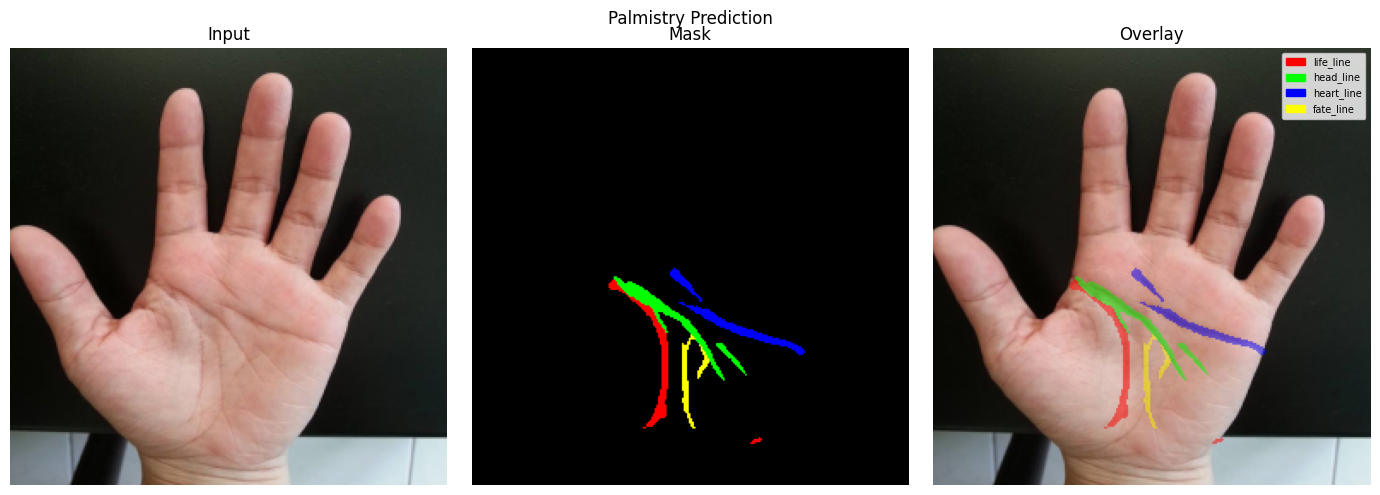

BÀI ĐỌC CHỈ TAY

Lưu ý:
  - Nội dung này chỉ mang tính tham khảo/giải trí theo palmistry và tử vi dân gian.
  - Không phải kết luận khoa học, y tế, tài chính hay dự đoán chắc chắn.

----------------------------------------------------------------------

▸ Đường Sinh Mệnh
----------------------------------------------------------------------
  Đặc điểm:
    - Độ dài: trung bình
    - Hình dạng: thẳng
    - Độ rõ: rõ
    - Tính liên tục: đứt đoạn
  Diễn giải:
    - Đường sinh mệnh trung bình nhưng có đứt đoạn thường biểu thị một đời sống có vài
    nhịp gián đoạn hoặc thay đổi đáng kể.
    - Không nhất thiết là xấu; trong palmistry, đường đứt có thể được hiểu là dấu mốc
    chuyển hóa.
    - Theo cách đọc kiểu tử vi, đây là người có 'vận trình đổi pha': mỗi lần thay đổi
    môi trường hoặc mục tiêu, bạn lại bước sang một phiên bản khác của chính mình.
    - Về sự nghiệp, có thể phù hợp với các ngành linh hoạt, thay đổi nhanh, hoặc công
    việc cần thích nghi.
    - Lời khuyên: nên chuẩn

In [37]:
# Run on new image
NEW_IMAGE_PATH = "/content/drive/MyDrive/1442132056-2057797398.png"  # ← Sửa path ảnh của bạn
RESULT_DIR = f"{BASE_DIR}/results"
features, reading = run_full_pipeline(NEW_IMAGE_PATH, best_model, RESULT_DIR)

In [31]:
# Save final model & rules
best_model.save(f"{CHECKPOINT_DIR}/palmistry_final.h5")
with open(f"{BASE_DIR}/palmistry_rules.json", "w", encoding="utf-8") as f:
    json.dump(PALMISTRY_RULES, f, ensure_ascii=False, indent=2)
print("Done! Model & rules saved.")

Done! Model & rules saved.


In [38]:
files.download(f'{BASE_DIR}/palmistry_rules.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>